In [ ]:
import sys
!{sys.executable} -m pip install scikit-learn imbalanced-learn xgboost scikit-image pillow matplotlib seaborn scipy

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from skimage.feature import graycomatrix, graycoprops
from skimage.color import rgb2gray, rgb2hsv
from skimage import img_as_ubyte

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score)
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

import xgboost as xgb

In [ ]:
import os
import zipfile

if not os.path.exists("HAM10000_images_part_1"):
    with zipfile.ZipFile("image/ham_images.zip", 'r') as zip_ref:
        zip_ref.extractall()

In [ ]:
import os
print(os.listdir())

['.git', '.gitignore', 'HAM10000_images_part_1', 'HAM10000_images_part_2', 'HAM10000_metadata.csv', 'hmnist_28_28_L.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_L.csv', 'hmnist_8_8_RGB.csv', 'image', 'load.ipynb', 'README.md']


In [ ]:
DATA_DIR = "."
META_CSV = "C:\\Users\\Shipra\\OneDrive\\Documents\\GitHub\\Skin-Lesion-Type-Classification-Using-Texture-and-Color-Features-with-SVM\\HAM10000_metadata.csv"

IMG_DIRS = [
    "C:\\Users\\Shipra\\OneDrive\\Documents\\GitHub\\Skin-Lesion-Type-Classification-Using-Texture-and-Color-Features-with-SVM\\HAM10000_images_part_1",
    "HAM10000_images_part_2"
]

IMG_SIZE = (128, 128)
RANDOM_SEED = 42

In [ ]:
import cv2

def load_image(image_id):
    img_name = image_id + ".jpg"
    
    for d in IMG_DIRS:
        path = os.path.join(d, img_name)
        if os.path.exists(path):
            return cv2.imread(path)
    
    return None

In [ ]:
import pandas as pd

df = pd.read_csv(META_CSV)

img = load_image(df.iloc[0]['image_id'])

print(img.shape)

(450, 600, 3)


In [ ]:
# 1.  LABEL MAP
# ─────────────────────────────────────────────
LABEL_MAP = {
    "mel":  "Melanoma",
    "bcc":  "Basal Cell Carcinoma",
    "akiec":"Actinic Keratoses",
    "bkl":  "Benign Keratosis",
    "df":   "Dermatofibroma",
    "nv":   "Melanocytic Nevi",
    "vasc": "Vascular Lesions",
}

In [ ]:
# ── Stage 2: Data loading + statistical summaries ──────────────────────────
df = pd.read_csv(META_CSV)
df['label_name'] = df['dx'].map(LABEL_MAP)

print(f"Total samples: {len(df)}")
print(f"Unique patients: {df['lesion_id'].nunique()}")
print(df[['dx','label_name']].value_counts())
print(df[['age','sex','localization']].describe(include='all'))

# Verify all images are findable
def get_image_path(image_id):
    for d in IMG_DIRS:
        path = os.path.join(d, image_id + ".jpg")
        if os.path.exists(path):
            return path
    return None

df['img_path'] = df['image_id'].apply(get_image_path)
missing = df['img_path'].isna().sum()
print(f"Missing images: {missing}")
df = df[df['img_path'].notna()].reset_index(drop=True)

Total samples: 10015
Unique patients: 7470
dx     label_name          
nv     Melanocytic Nevi        6705
mel    Melanoma                1113
bkl    Benign Keratosis        1099
bcc    Basal Cell Carcinoma     514
akiec  Actinic Keratoses        327
vasc   Vascular Lesions         142
df     Dermatofibroma           115
Name: count, dtype: int64
                age    sex localization
count   9958.000000  10015        10015
unique          NaN      3           15
top             NaN   male         back
freq            NaN   5406         2192
mean      51.863828    NaN          NaN
std       16.968614    NaN          NaN
min        0.000000    NaN          NaN
25%       40.000000    NaN          NaN
50%       50.000000    NaN          NaN
75%       65.000000    NaN          NaN
max       85.000000    NaN          NaN
Missing images: 0


In [ ]:
# ── Stage 3: Preprocessing pipeline ────────────────────────────────────────
import cv2

def preprocess_image(img_path, size=IMG_SIZE):
    """Load, resize, convert BGR→RGB, normalize to [0,1]."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img  # uint8, shape (128, 128, 3)

def remove_hair(img):
    """
    Inpainting-based hair removal.
    Detects dark thin structures and fills them.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    cleaned = cv2.inpaint(img, mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    return cleaned

# Build preprocessed image array and save to disk
PROCESSED_NPY = "processed_images.npy"
PROCESSED_IDS = "processed_ids.npy"

if not os.path.exists(PROCESSED_NPY):
    images, ids = [], []
    for _, row in df.iterrows():
        img = preprocess_image(row['img_path'])
        if img is not None:
            img = remove_hair(img)
            images.append(img)
            ids.append(row['image_id'])
    images = np.array(images, dtype=np.uint8)
    np.save(PROCESSED_NPY, images)
    np.save(PROCESSED_IDS, np.array(ids))
    print(f"Saved {len(images)} preprocessed images → {PROCESSED_NPY}")
else:
    images = np.load(PROCESSED_NPY)
    ids    = np.load(PROCESSED_IDS)
    print(f"Loaded {len(images)} preprocessed images from cache")

# Align df to saved order
id_to_idx = {iid: i for i, iid in enumerate(ids)}
df = df[df['image_id'].isin(id_to_idx)].copy()
df['proc_idx'] = df['image_id'].map(id_to_idx)
df = df.sort_values('proc_idx').reset_index(drop=True)
images = images[df['proc_idx'].values]

Saved 10014 preprocessed images → processed_images.npy


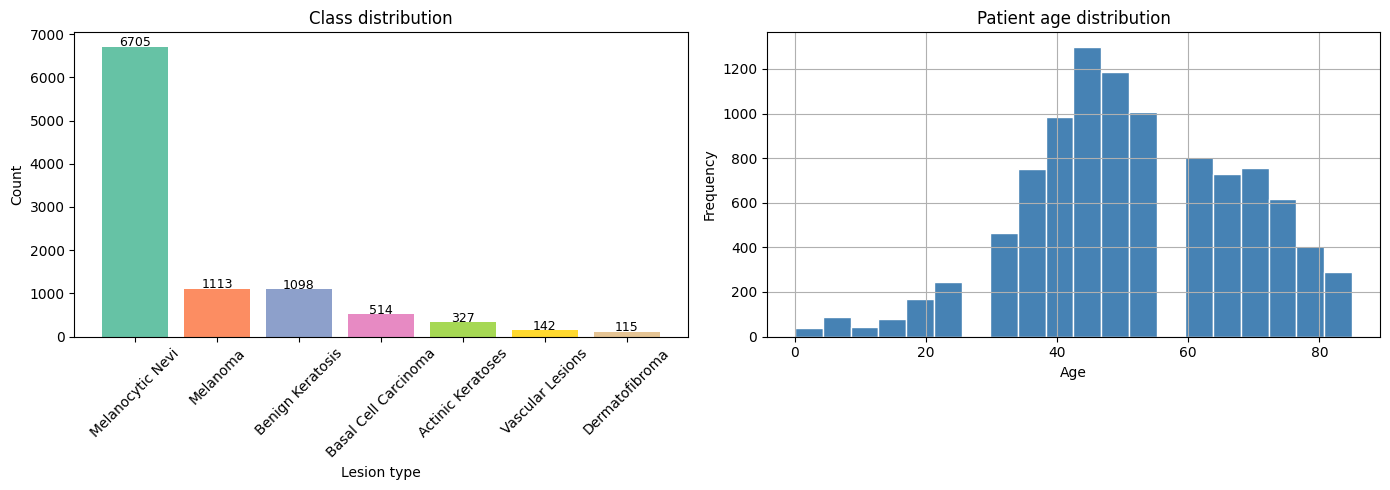

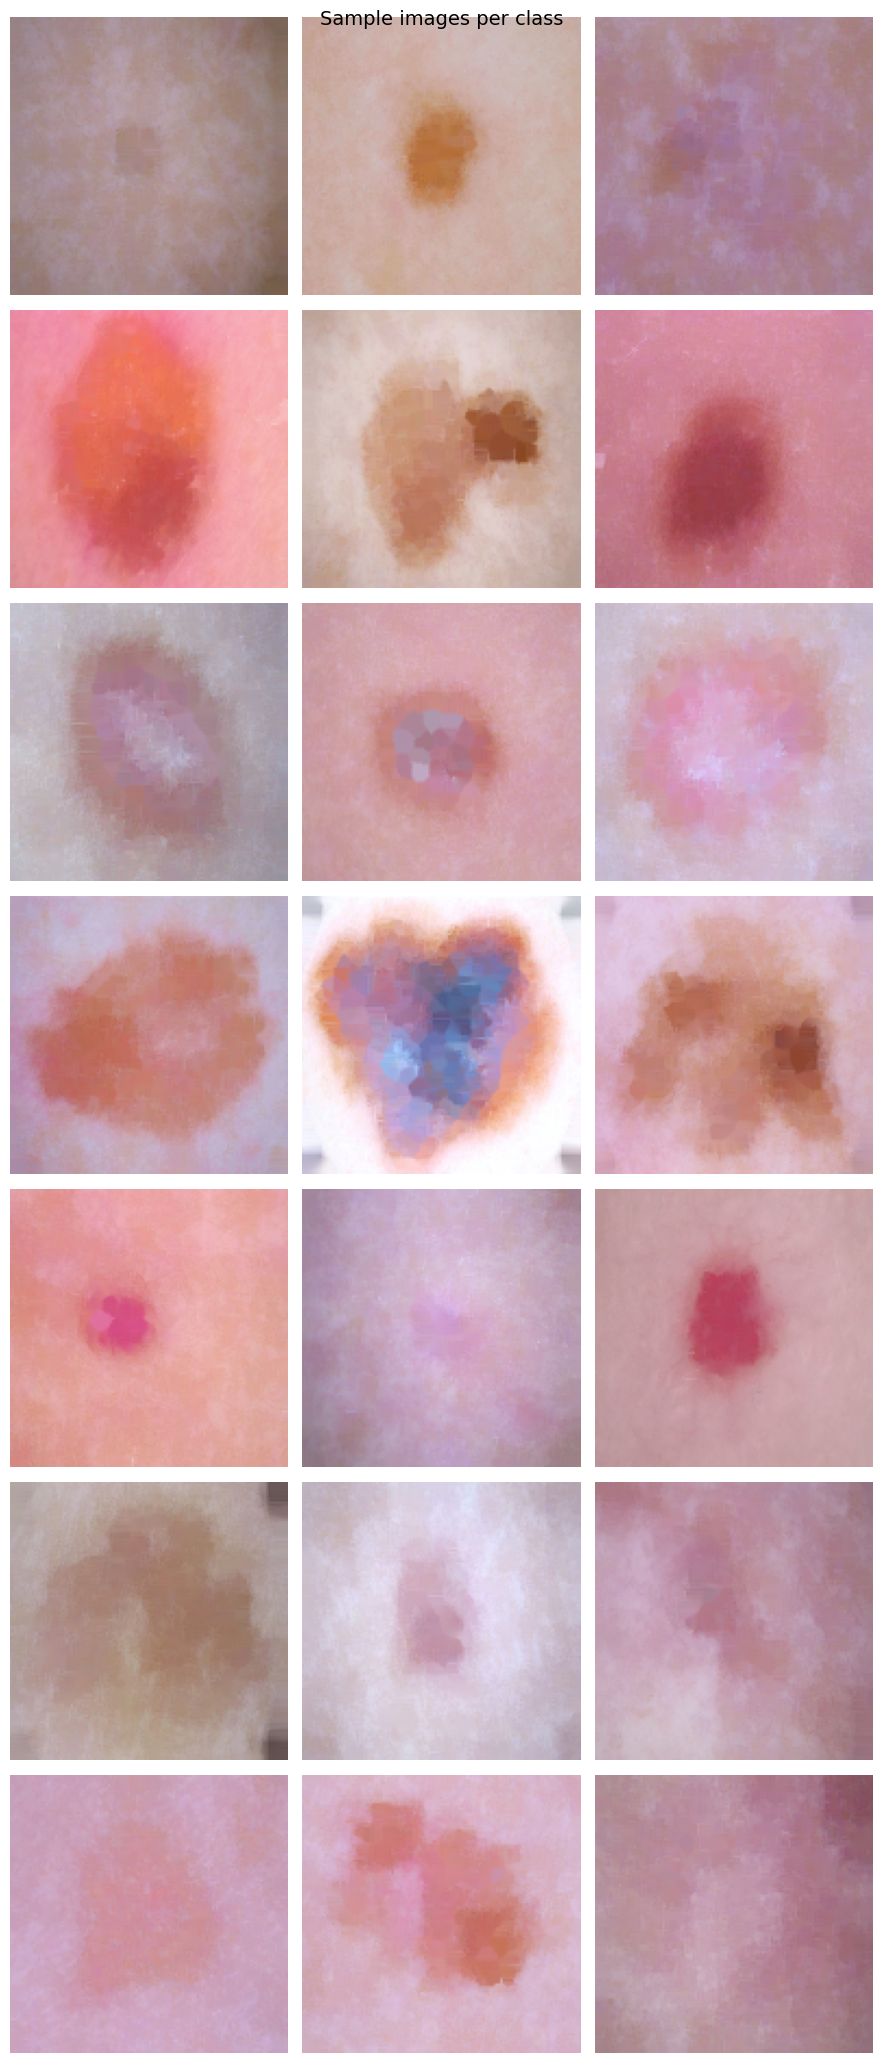

In [ ]:
# ── Stage 4: EDA ─────────────────────────────────────────────────────────
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['label_name'].value_counts()
axes[0].bar(counts.index, counts.values, color=sns.color_palette("Set2", len(counts)))
axes[0].set_title("Class distribution")
axes[0].set_xlabel("Lesion type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=9)

# Age distribution
df['age'].dropna().hist(ax=axes[1], bins=20, color='steelblue', edgecolor='white')
axes[1].set_title("Patient age distribution")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("eda_class_age.png", dpi=150)
plt.show()

# Sample image grid — 3 images per class
classes = df['label_name'].unique()
fig, axes = plt.subplots(len(classes), 3, figsize=(9, len(classes) * 3))
fig.suptitle("Sample images per class", fontsize=14)

for row_i, cls in enumerate(classes):
    samples = df[df['label_name'] == cls].sample(min(3, len(df[df['label_name']==cls])),
                                                   random_state=RANDOM_SEED)
    for col_i, (_, sample) in enumerate(samples.iterrows()):
        ax = axes[row_i][col_i]
        ax.imshow(images[df.index[df['image_id'] == sample['image_id']][0]])
        ax.axis('off')
        if col_i == 0:
            ax.set_ylabel(cls, fontsize=8, rotation=0, labelpad=60, va='center')

plt.tight_layout()
plt.savefig("eda_sample_grid.png", dpi=150)
plt.show()

In [ ]:
# ── Stage 5: HSV histogram feature extraction ──────────────────────────────
def extract_hsv_histogram(img, bins=16):
    """
    Convert to HSV and compute normalized histogram
    for each channel (H, S, V). Returns 48-dim vector.
    """
    hsv = rgb2hsv(img)  # skimage returns float64 in [0,1]
    features = []
    for channel in range(3):
        hist, _ = np.histogram(hsv[:, :, channel], bins=bins, range=(0, 1))
        hist = hist.astype(float) / (hist.sum() + 1e-7)  # normalize
        features.extend(hist)
    return np.array(features)

HSV_NPY = "hsv_features.npy"

if not os.path.exists(HSV_NPY):
    hsv_features = np.array([extract_hsv_histogram(img) for img in images])
    np.save(HSV_NPY, hsv_features)
    print(f"HSV features shape: {hsv_features.shape}")  # (N, 48)
else:
    hsv_features = np.load(HSV_NPY)
    print(f"Loaded HSV features: {hsv_features.shape}")

HSV features shape: (10014, 48)


In [ ]:
# ── Stage 6: SMOTE ─────────────────────────────────────────────────────────
# Expects: X_train (feature matrix), y_train (encoded labels)
# Call this AFTER train/test split, BEFORE model training.

from imblearn.over_sampling import SMOTE

def apply_smote(X_train, y_train, random_state=RANDOM_SEED):
    print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))
    smote = SMOTE(random_state=random_state, k_neighbors=5)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    print("After  SMOTE:", dict(zip(*np.unique(y_res, return_counts=True))))
    return X_res, y_res

# Example usage (call this once features are merged with M2):
# X_train_bal, y_train_bal = apply_smote(X_train, y_train)

In [ ]:
# ── Stage 7: Evaluation visualization ────────────────────────────────────
# Called after M3 produces y_test, y_pred, y_proba

def plot_confusion_matrix(y_test, y_pred, class_names):
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Confusion matrix")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()

def plot_per_class_accuracy(y_test, y_pred, class_names):
    report = classification_report(y_test, y_pred,
                                   target_names=class_names, output_dict=True)
    accs = [report[c]['recall'] for c in class_names]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(class_names, accs, color=sns.color_palette("Set2", len(class_names)))
    ax.set_ylim(0, 1)
    ax.set_ylabel("Recall (per-class accuracy)")
    ax.set_title("Per-class accuracy")
    ax.tick_params(axis='x', rotation=45)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{acc:.2f}", ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig("per_class_accuracy.png", dpi=150)
    plt.show()